# ML - Aprendizaje No Supervisado
## K-Means con Dataset Iris — 3 Variables

El aprendizaje no supervisado busca **descubrir patrones ocultos** en los datos sin necesidad de etiquetas. A diferencia del aprendizaje supervisado donde los datos ya tienen respuestas, aquí el algoritmo agrupa los datos por similitud por sí solo.

## Descripción del Dataset: Iris

### ¿De qué se trata?

El dataset **Iris** es uno de los más famosos en Machine Learning. Contiene mediciones físicas de **150 flores** pertenecientes a 3 especies distintas de la planta Iris, con 50 flores por especie.

### ¿Qué contiene?

| Columna | Tipo | Descripción |
|---|---|---|
| **sepal_length** | Numérico | Longitud del sépalo en cm |
| **sepal_width** | Numérico | Ancho del sépalo en cm |
| **petal_length** | Numérico | Longitud del pétalo en cm |
| **petal_width** | Numérico | Ancho del pétalo en cm |
| **species** | Categórico | Especie: Iris-setosa, Iris-versicolor, Iris-virginica |

### ¿Para qué sirve?

El objetivo es aplicar **K-Means Clustering** para ver si el algoritmo es capaz de **descubrir las 3 especies por sí solo**, usando solo las medidas numéricas sin conocer las etiquetas de especie.

### Columnas utilizadas en este notebook (3 variables)

Usaremos las 3 columnas del pétalo + sépalo más discriminativas:
- **`sepal_length`** → longitud del sépalo
- **`petal_length`** → longitud del pétalo
- **`petal_width`** → ancho del pétalo

Con 3 variables la visualización se hace en **3D**, lo que permite ver mejor la separación entre especies.

## 1. Carga del Dataset

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Carga del archivo iris.txt (sin encabezado, separado por comas)
df = pd.read_csv('iris.txt', header=None,
                 names=['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species'])

print("Primeras filas del dataset:")
print(df.head(10))
print(f"\nDimensiones: {df.shape[0]} flores, {df.shape[1]} columnas")
print(f"\nEspecies únicas: {df['species'].unique()}")
print("\nEstadísticas descriptivas:")
print(df.describe())

Primeras filas del dataset:
   sepal_length  sepal_width  petal_length  petal_width      species
0           5.1          3.5           1.4          0.2  Iris-setosa
1           4.9          3.0           1.4          0.2  Iris-setosa
2           4.7          3.2           1.3          0.2  Iris-setosa
3           4.6          3.1           1.5          0.2  Iris-setosa
4           5.0          3.6           1.4          0.2  Iris-setosa
5           5.4          3.9           1.7          0.4  Iris-setosa
6           4.6          3.4           1.4          0.3  Iris-setosa
7           5.0          3.4           1.5          0.2  Iris-setosa
8           4.4          2.9           1.4          0.2  Iris-setosa
9           4.9          3.1           1.5          0.1  Iris-setosa

Dimensiones: 150 flores, 5 columnas

Especies únicas: <StringArray>
['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
Length: 3, dtype: str

Estadísticas descriptivas:
       sepal_length  sepal_width  petal_l

## 2. Selección de 3 Variables

In [4]:
# Seleccionamos 3 columnas numéricas para el clustering
X = df[['sepal_length', 'petal_length', 'petal_width']].values

print("Shape de X:", X.shape)
print("Primeros 5 valores:\n", X[:5])

Shape de X: (150, 3)
Primeros 5 valores:
 [[5.1 1.4 0.2]
 [4.9 1.4 0.2]
 [4.7 1.3 0.2]
 [4.6 1.5 0.2]
 [5.  1.4 0.2]]


## 3. Visualización Inicial (sin clusters)

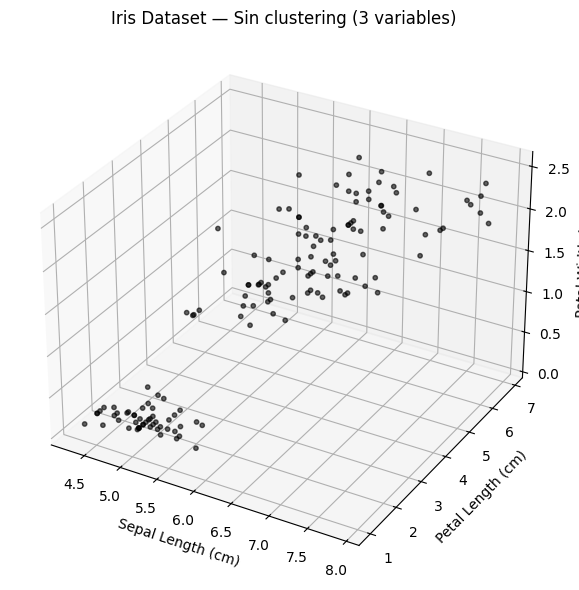

In [5]:
fig = plt.figure(figsize=(9, 6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X[:, 0], X[:, 1], X[:, 2], c='black', s=10, alpha=0.6)
ax.set_xlabel('Sepal Length (cm)')
ax.set_ylabel('Petal Length (cm)')
ax.set_zlabel('Petal Width (cm)')
ax.set_title('Iris Dataset — Sin clustering (3 variables)')
plt.tight_layout()
plt.show()

## 4. Entrenamiento K-Means (k=3)

In [6]:
from sklearn.cluster import KMeans

k = 3  # 3 clusters = 3 especies de iris
kmeans = KMeans(n_clusters=k, random_state=42)
y_pred = kmeans.fit_predict(X)

print("Etiquetas asignadas (primeras 20):", y_pred[:20])
print("\nCentroides encontrados:")
print(pd.DataFrame(kmeans.cluster_centers_,
                   columns=['sepal_length', 'petal_length', 'petal_width']))

Etiquetas asignadas (primeras 20): [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]

Centroides encontrados:
   sepal_length  petal_length  petal_width
0      6.810000      5.707500        2.075
1      5.006000      1.464000        0.244
2      5.896667      4.371667        1.410


In [8]:
print("centroides:\n")
kmeans.cluster_centers_

centroides:



array([[6.81      , 5.7075    , 2.075     ],
       [5.006     , 1.464     , 0.244     ],
       [5.89666667, 4.37166667, 1.41      ]])

## 5. Visualización de Clusters en 3D

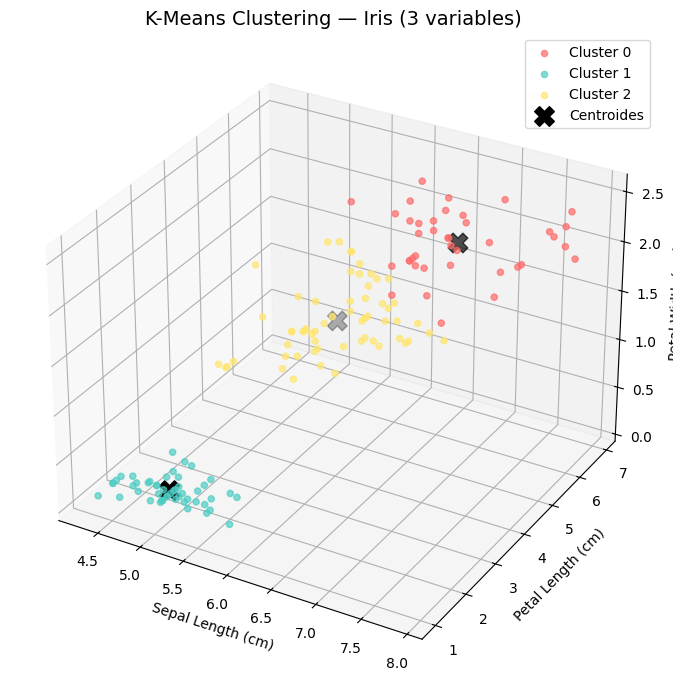

In [5]:
colores = ['#FF6B6B', '#4ECDC4', '#FFE66D']
nombres_clusters = ['Cluster 0', 'Cluster 1', 'Cluster 2']

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Puntos coloreados por cluster
for i in range(k):
    mask = y_pred == i
    ax.scatter(X[mask, 0], X[mask, 1], X[mask, 2],
               c=colores[i], s=20, label=nombres_clusters[i], alpha=0.7)

# Centroides
centroids = kmeans.cluster_centers_
ax.scatter(centroids[:, 0], centroids[:, 1], centroids[:, 2],
           c='black', s=200, marker='X', zorder=10, label='Centroides')

ax.set_xlabel('Sepal Length (cm)')
ax.set_ylabel('Petal Length (cm)')
ax.set_zlabel('Petal Width (cm)')
ax.set_title('K-Means Clustering — Iris (3 variables)', fontsize=14)
ax.legend()
plt.tight_layout()
plt.show()

## 6. Predicción de Nuevas Flores

In [6]:
# Predecir el cluster de nuevas flores [sepal_length, petal_length, petal_width]
X_new = np.array([[5.0, 1.4, 0.2],   # probable setosa
                  [6.5, 4.5, 1.5],   # probable versicolor
                  [7.0, 6.0, 2.0]])  # probable virginica

predicciones = kmeans.predict(X_new)
for i, pred in enumerate(predicciones):
    print(f"Flor {i+1} {X_new[i]} → Cluster {pred}")

Flor 1 [5.  1.4 0.2] → Cluster 1
Flor 2 [6.5 4.5 1.5] → Cluster 2
Flor 3 [7. 6. 2.] → Cluster 0


## 7. Comparación: Clusters vs Especies Reales

In [7]:
df['cluster'] = y_pred
print("Distribución de especies por cluster:")
print(pd.crosstab(df['cluster'], df['species']))

Distribución de especies por cluster:
species  Iris-setosa  Iris-versicolor  Iris-virginica
cluster                                              
0                  0                2              38
1                 50                0               0
2                  0               48              12
